<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/avcd_exerc1_wordcloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis and Visualization of Complex Data
---
## Exercise 01 - Create your personal word cloud

In this exercise you will produce your personal word cloud using python

First, we need to install the `wordcloud` package, which provides the functionality to generate word clouds, and `PyPDF2` to extract text from the PDF file.

In [1]:
import sys

# Install wordcloud library
!{sys.executable} -m pip install wordcloud pypdf2

# It's good practice to restart the runtime after installing new packages.
# You can do this from the Runtime menu > Restart runtime, or by running `import os; os.kill(os.getpid(), 9)`
# However, for convenience in this notebook, we'll proceed without restarting.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.0 MB/s eta 0:00:00


Next, let's import all the necessary libraries.

In [2]:
# Import the pandas library for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations and array handling
import numpy as np

# Import the os module to interact with the operating system
import os

# Import matplotlib's pyplot module for creating and displaying visualizations
import matplotlib.pyplot as plt

# Import WordCloud class to generate word clouds
# Import STOPWORDS to access the default list of common words to exclude
from wordcloud import WordCloud, STOPWORDS

# Import PyPDF2 for reading PDF files
from PyPDF2 import PdfReader

# Import the Image module from PIL (Pillow) for image manipulation
from PIL import Image

Now, let's extract the text from your CV (`CV_Catarina_Silva.pdf`).

In [3]:
pdf_path = '/content/CV_Catarina_Silva.pdf'

text = ""
with open(pdf_path, 'rb') as file:
    reader = PdfReader(file)
    for page in reader.pages:
        text += page.extract_text() + "\n"

# Print the first 500 characters to verify content
print(text[:500])

        +351 911 131 954
        catarinamsilva.98@gmail.com
        São Domingos de Rana, Cascais, Lisboa
        19/03/1998
CONTACTS:
VALUES/SKILLS:
Responsability
Team spirit
Eager to learn
Communication
Respect
Commitmentcatarina silva
Hardworking, detail-oriented and organized BSc
Biology graduate that grew knowledge in data
analytics.
Interested in developing new digital skills in
areas of the environmental sciences, focusing
on information analysis and computing.
Seeking to expand academi


Next, we'll create a list of stopwords. These are common words that you don't want to include in your word cloud (e.g., 'the', 'is', 'a', etc.), plus any custom words you want to exclude.

In [4]:
# Create a set of default stopwords provided by the wordcloud library
stopwords = set(STOPWORDS)

# Add additional custom words to the stopwords set that might appear frequently in a CV
stopwords.update([
    "Segurado", "Ferreira", "Aguiar", "Branco", "Schinegger", "Borja", "Reino", "Haidvogl", "Hermoso", "Filipe", "doi", "Araújo", "Teixeira", "Godinho", "Carreira", "dx", "based", "Total environment", "Oliveira", "Santos", "Almeida", "Catry", "Duarte", "Beja", "Rebelo", "Neves", "Pereira", "Pont", "Costa", "Feld", "Journal", "Using", "Research", "scitotenv", "J", "P", "G", "M", "V", "J","F", "T", "N" ,"C", "B", "S", "W", "de", "https", "D", "L", "E", "Science", "org", "Total", "Environment", # From original example
    "curriculum", "vitae", "email", "phone", "linkedin", "github", "experience", "education", "skills", "project", "management", "data", "analysis", "python", "university", "bachelor", "master", "phd", "work", "team", "developer", "scientist", "engineer", "report", "presentation", "communication", "research", "publications", "international", "national", "conference", "workshop", "award", "honors", "references", "available", "upon", "request", "summary", "profile", "areas", "expertise", "professional", "development", "certificates", "training", "language", "english", "portuguese", "spanish", "german", "french", "degree", "program", "institution", "achievements", "responsibilities", "volunteering", "interests", "hobbies", "personal", "details", "address", "date", "birth", "citizenship", "nationality", "married", "single", "from", "with", "and", "for", "the", "that", "this", "will", "was", "are", "have", "been", "can", "has", "not", "such", "also", "etc", "e.g", "i.e", "may", "new", "old", "well", "get", "use", "used", "make", "made", "like", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten", "within", "through", "which", "what", "where", "when", "why", "how", "who", "whom", "whose", "much", "many", "more", "most", "other", "there", "then", "than", "them", "they", "their", "this", "that", "these", "those", "very", "want", "need", "must", "should", "could", "would", "always", "never", "often", "seldom", "sometimes", "always", "often", "rarely", "frequently", "usually", "rarely", "however", "therefore", "thus", "hence", "because", "since", "while", "whereas", "meanwhile", "although", "even", "though", "unless", "until", "before", "after", "during", "since", "between", "among", "across", "along", "around", "at", "by", "down", "up", "in", "on", "off", "over", "under", "out", "into", "onto", "from", "to", "with", "without", "through", "about", "above", "below", "beside", "behind", "in", "front", "of", "near", "far", "opposite", "outside", "inside", "upon", "upon", "past", "towards", "via", "etc.", "i.e.", "e.g.", "p.", "pp.", "vol.", "no.", "ed.", "eds.", "fig.", "figs.", "et", "al.", "vs.", "cf.", "ca.", "approx.", "min.", "max.", "avg.", "std.", "dev.", "hr.", "hrs.", "day.", "days.", "week.", "weeks.", "month.", "months.", "year.", "years.", "sec.", "secs.", "min.", "max.", "avg.", "std.", "dev.", "hr.", "hrs.", "day.", "days.", "week.", "weeks.", "month.", "months.", "year.", "years.", "sec.", "secs.", "km.", "m.", "cm.", "mm.", "kg.", "g.", "mg.", "ml.", "l.", "mph.", "kph.", "gdp.", "usd.", "eur.", "gbp.", "yen.", "etc.", "i.e.", "e.g.", "p.", "pp.", "vol.", "no.", "ed.", "eds.", "fig.", "figs.", "et", "al.", "vs.", "cf.", "ca.", "approx.", "min.", "max.", "avg.", "std.", "dev.", "hr.", "hrs.", "day.", "days.", "week.", "weeks.", "month.", "months.", "year.", "years.", "sec.", "secs."])

print(f"Number of stopwords: {len(stopwords)}")

Number of stopwords: 427


Now, let's generate and display a basic word cloud from the extracted text using the defined stopwords.

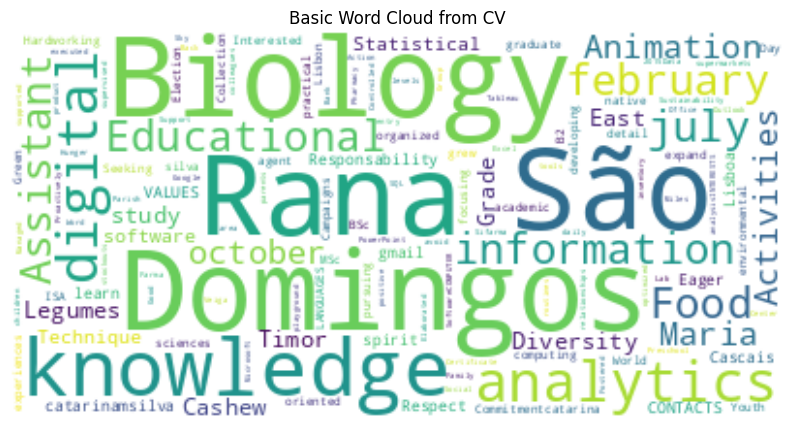

In [5]:
# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords, background_color="white", max_words=200).generate(text)

# Display the generated image using matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear') # 'interpolation="bilinear"' smooths the image
plt.axis("off") # Remove the x and y axes
plt.title('Basic Word Cloud from CV')
plt.show()

We can customize the appearance of the word cloud by setting parameters like `max_font_size`, `background_color`, `width`, and `height`.

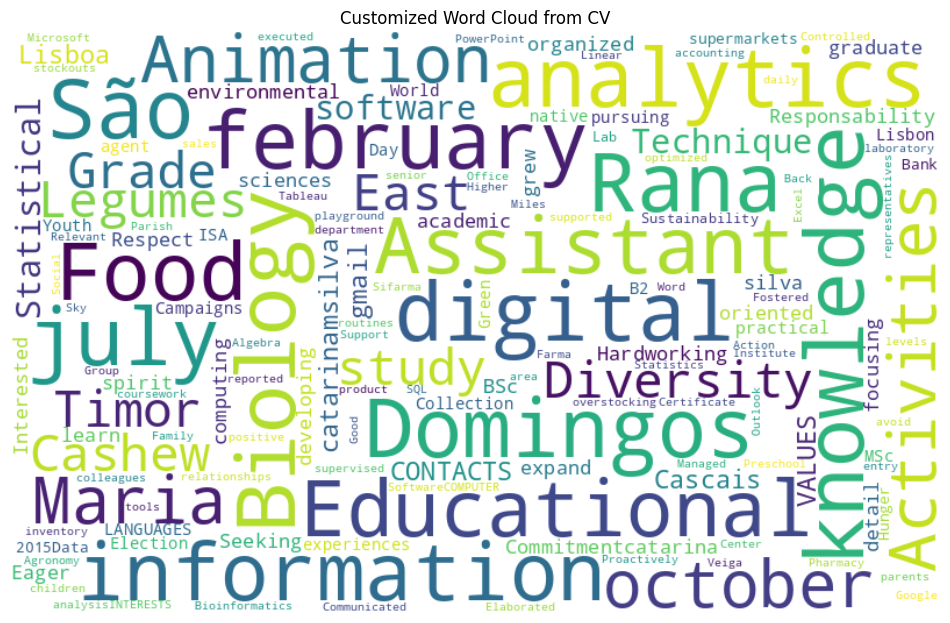

Customized word cloud saved as wordcloud_CV.png


In [6]:
# Create a WordCloud object with customized settings
wordcloud_custom = WordCloud(
    stopwords=stopwords,
    max_font_size=70,
    background_color="white",
    width=800,
    height=500,
    max_words=150
).generate(text)

# Display the WordCloud image
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_custom, interpolation='bilinear')
plt.axis("off")
plt.title('Customized Word Cloud from CV')
plt.show()

# Optionally save the image
wordcloud_custom.to_file("wordcloud_CV.png")
print("Customized word cloud saved as wordcloud_CV.png")

You can also plot your keywords within a specific shape by using an image mask. We will use the `turtle.png` file for this.

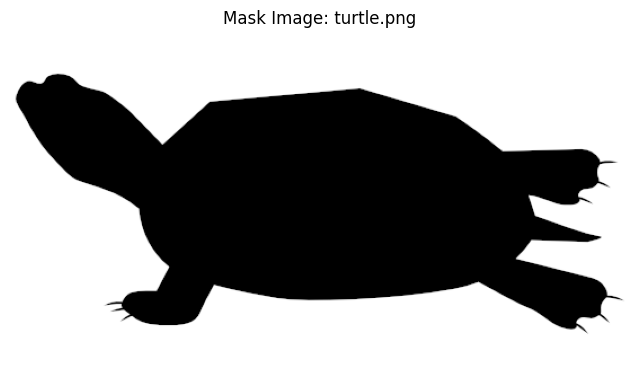

In [7]:
turtle_mask_path = '/content/turtle.png'

# Open the image file (turtle.png) using PIL and convert it into a NumPy array
turtle_mask = np.array(Image.open(turtle_mask_path))

# Display the mask image to visually confirm it loaded correctly
plt.figure(figsize=(8, 8))
plt.imshow(turtle_mask, cmap=plt.cm.gray) # Use a grayscale colormap
plt.axis("off")
plt.title('Mask Image: turtle.png')
plt.show()

Finally, let's create a word cloud shaped like the turtle image.

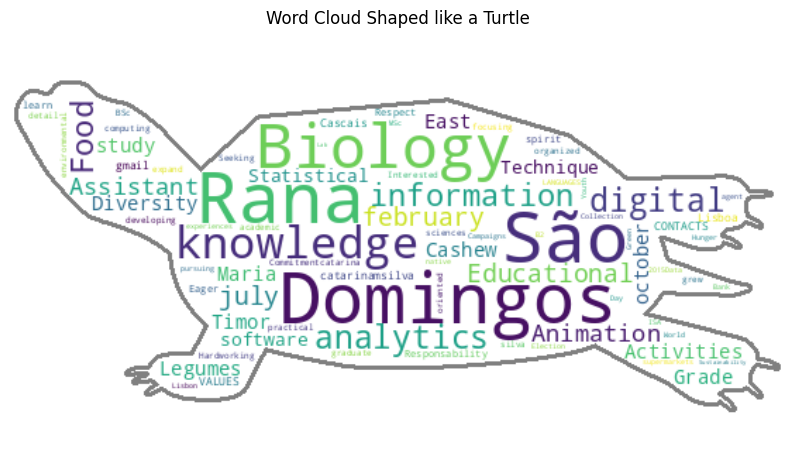

Masked word cloud saved as turtle_wordcloud.png


In [8]:
# Create a WordCloud object with customized settings and the mask
wc_masked = WordCloud(
    background_color="white",
    max_words=500,
    mask=turtle_mask,
    stopwords=stopwords,
    contour_width=2,
    repeat=True, # Allow words to repeat to better fill the mask shape
    max_font_size=50,
    contour_color='grey'
)

# Generate the word cloud from the text data
wc_masked.generate(text)

# Save the generated WordCloud image to a file
wc_masked.to_file("turtle_wordcloud.png")

# Create a matplotlib figure with custom size
plt.figure(figsize=[10, 10])

# Display the generated WordCloud image
plt.imshow(wc_masked, interpolation='bilinear')

# Remove axes
plt.axis("off")
plt.title('Word Cloud Shaped like a Turtle')
plt.show()

print("Masked word cloud saved as turtle_wordcloud.png")


###Questions

- The world cloud you just produced is based on how many variables? **The word cloud I produced is based on one variable which is the text content extracted from my PDF.**

- Which is the type of each variable in your word cloud? **The text content is a string, and within the word cloud, the size of each word is a quantitative variable representing its frequency.**

#References

[Generating WordClouds in Python Tutorial](https://www.google.com/url?q=https%3A%2F%2Fwww.datacamp.com%2Ftutorial%2Fwordcloud-python)

[Python Wordcloud Tutorial](https://www.google.com/url?q=https%3A%2F%2Fpython-course.eu%2Fapplications-python%2Fpython-wordcloud-tutorial.php)

[How to create a word cloud in Python?](https://www.google.com/url?q=https%3A%2F%2Fwww.projectpro.io%2Frecipes%2Fcreate-word-cloud-python)